<a href="https://colab.research.google.com/github/NahomiHM/Procesos-estocasticos/blob/main/Tutorial_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Tutorial de Sympy y Networkx

Escriba en una notebook un breve tutorial que explique cómo representar matrices, obtener una entrada dada (columna, renglón o entrada especifica), multiplicar matrices, elevarlas a una potencia dada, multiplicar vectores por matrices y hallar valores y vectores propios, en la librería Sympy.

In [ ]:
import sympy as sp #Librerias necesarias para hacer el codigo

# Mejora la visualización de las matrices
sp.init_printing()
# Definimos variables simbólicas por si las necesitamos
x, y = sp.symbols('x y')


Para crear una matriz, usamos $sp.Matrix()$

In [ ]:
#  matriz de 3x3 usando una lista
A = sp.Matrix([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

#  matriz de incognitas es parecida a lo anterior solo que con letras
M_simb = sp.Matrix([[x, x+y], [y, 1]])

#vemos como sale las matrices
print("Matriz A:")
display(A)
print("Matriz con símbolos:")
display(M_simb)

Matriz A:


⎡1  2  3⎤
⎢       ⎥
⎢4  5  6⎥
⎢       ⎥
⎣7  8  9⎦

Matriz con símbolos:


⎡x  x + y⎤
⎢        ⎥
⎣y    1  ⎦

Acceder a Entradas (Filas, Columnas o Celdas)

$Nota$: el conteo empieza en 0 en python, si se tiene una lista la entrada uno es la entrada cero

In [ ]:
# Entrada específica (Renglón 1, Columna 2) -> Valor 6
entrada = A[1, 2]

# Obtener un renglón completo (Renglón 0)
renglon = A.row(0)

# Obtener una columna completa (Columna 1)
columna = A.col(1)

print(f"Entrada [1,2]: {entrada}")
display(renglon, columna)

Entrada [1,2]: 6


[1  2  3]

⎡2⎤
⎢ ⎥
⎢5⎥
⎢ ⎥
⎣8⎦

Operaciones Básicas: Multiplicación y Potencia
1.   multiplicar operador *.
2.   elevar a una potencia  **

In [ ]:
B = sp.Matrix([[1, 0, 1], [0, 1, 2], [1, 1, 0]])

# Multiplicación de matrices
producto = A * B

# Elevar una matriz al cuadrado (A^2)
potencia = A**2

display(producto, potencia)

⎡4   5   5 ⎤
⎢          ⎥
⎢10  11  14⎥
⎢          ⎥
⎣16  17  23⎦

⎡30   36   42 ⎤
⎢             ⎥
⎢66   81   96 ⎥
⎢             ⎥
⎣102  126  150⎦

Multiplicar Vectores por Matrices
Un vector en SymPy se representa simplemente como una matriz de una sola columna (vector columna) o una sola fila (vector renglón)

In [ ]:
# Definir un vector columna
v = sp.Matrix([1, 2, 3])

# Multiplicación Matriz * Vector
resultado_v = A * v

display(resultado_v)

⎡14⎤
⎢  ⎥
⎢32⎥
⎢  ⎥
⎣50⎦

Valores y Vectores Propios (Eigenvalues & Eigenvectors)

$eigenvals()$: Devuelve un diccionario donde la llave es el valor propio y el valor es su multiplicidad.

$eigenvects()$: Devuelve una lista de tuplas: (valor propio, multiplicidad, [vectores propios])

In [ ]:
# Usaremos una matriz más sencilla para que los valores sean claros
C = sp.Matrix([[3, -2], [4, -1]])

# Hallar valores propios
valores_p = C.eigenvals()

# Hallar vectores propios
vectores_p = C.eigenvects()

print("Valores propios (Valor: Multiplicidad):")
display(valores_p)

print("Vectores propios:")
display(vectores_p)

Valores propios (Valor: Multiplicidad):


{1 - 2⋅ⅈ: 1, 1 + 2⋅ⅈ: 1}

Vectores propios:


⎡⎛            ⎡⎡1   ⅈ⎤⎤⎞  ⎛            ⎡⎡1   ⅈ⎤⎤⎞⎤
⎢⎜            ⎢⎢─ - ─⎥⎥⎟  ⎜            ⎢⎢─ + ─⎥⎥⎟⎥
⎢⎜1 - 2⋅ⅈ, 1, ⎢⎢2   2⎥⎥⎟, ⎜1 + 2⋅ⅈ, 1, ⎢⎢2   2⎥⎥⎟⎥
⎢⎜            ⎢⎢     ⎥⎥⎟  ⎜            ⎢⎢     ⎥⎥⎟⎥
⎣⎝            ⎣⎣  1  ⎦⎦⎠  ⎝            ⎣⎣  1  ⎦⎦⎠⎦

##NetworkX
 librería estándar para manejar grafos y redes


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Configuración para que los gráficos se vean nítidos en Colab
%config InlineBackend.figure_format = 'retina'

En investigación de operaciones, los diagramas de transición representan estados y las flechas indican la probabilidad o el costo de pasar de un estado a otro

$nx.DiGraph() $ porque las transiciones tienen dirección.

In [ ]:
# Crear el objeto de Grafo Dirigido
G = nx.DiGraph()

# Definir los estados (Nodos)
estados = ["Estado A", "Estado B", "Estado C"]
G.add_nodes_from(estados)

# Definir las transiciones (Aristas con pesos/probabilidades)
# Estructura: (Origen, Destino, Peso)
transiciones = [
    ("Estado A", "Estado B", 0.3),
    ("Estado A", "Estado A", 0.7),
    ("Estado B", "Estado C", 0.5),
    ("Estado B", "Estado A", 0.5),
    ("Estado C", "Estado A", 1.0)
]

# Añadir las aristas al grafo
for origen, destino, peso in transiciones:
    G.add_edge(origen, destino, weight=peso)

Para que un diagrama de transición sea legible necesitamos posicionar los nodos y dibujar las etiquetas de los pesos (probabilidades)




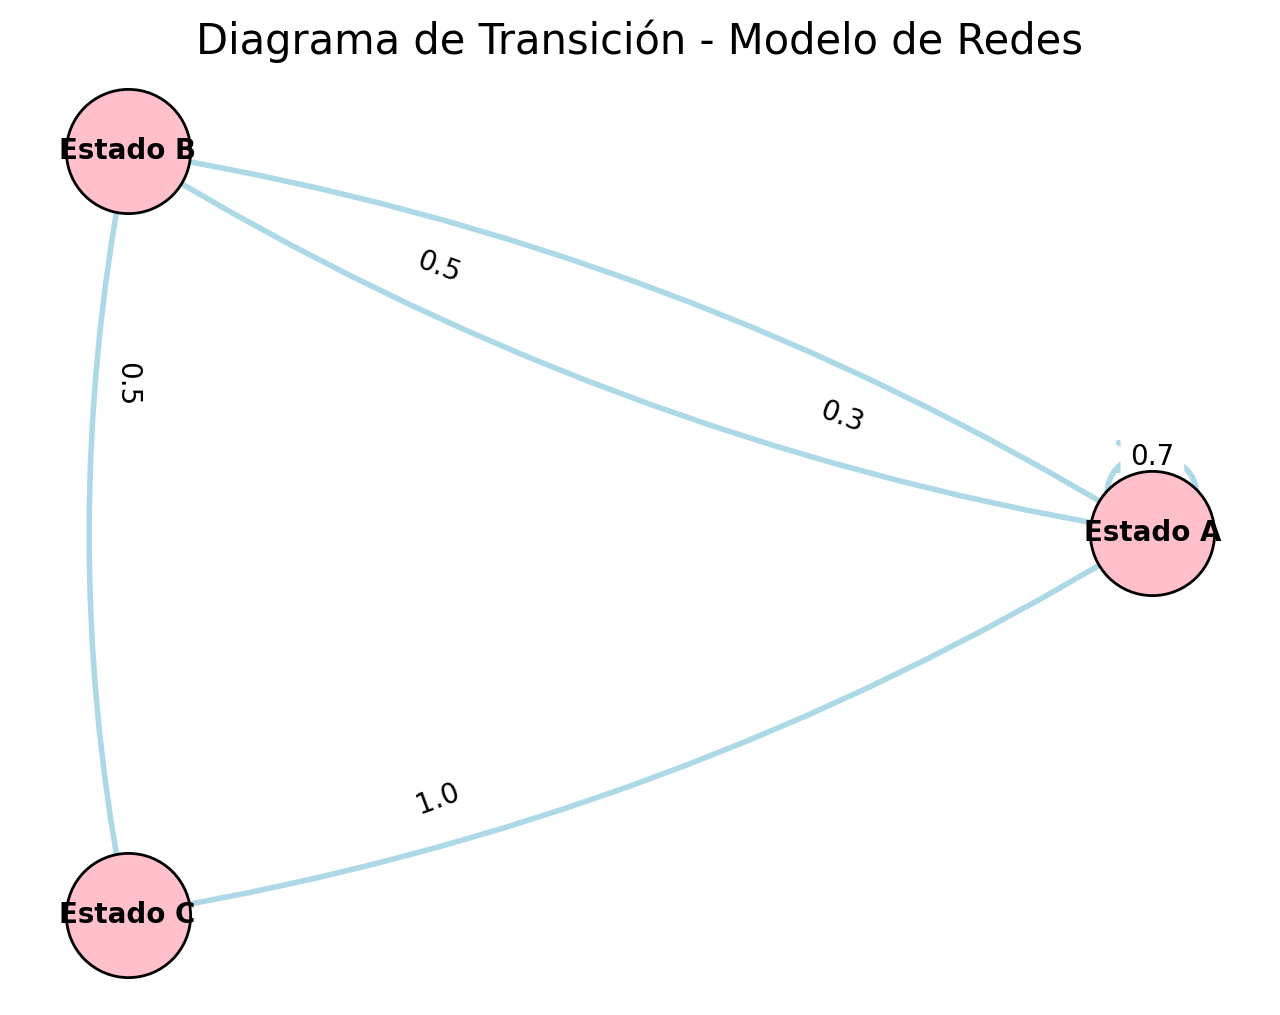

In [ ]:
#a posición de los nodos (layout circular es común en transiciones)
pos = nx.circular_layout(G)

# l tamaño del lienzo
plt.figure(figsize=(8, 6))

#  Nodos
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='pink', edgecolors='black')

# Flechas
# 'connectionstyle' permite que las flechas sean curvas si hay transiciones de ida y vuelta
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=25,
                       edge_color='lightblue', width=2,
                       connectionstyle='arc3,rad=0.1')

#Dibujar Etiquetas de los Nodos
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_weight='bold')

# Pesos de las Aristas (Probabilidades)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, label_pos=0.3, font_color='black')

plt.title("Diagrama de Transición - Modelo de Redes", fontsize=15)
plt.axis('off') # Quitar ejes
plt.show()


Obtener la Matriz deTransición
Puedes convertir tu diagrama directamente a una matriz de$SymPy$ o $NumPy$ para como hallar el estado estacionario



In [ ]:
import sympy as sp

# Obtener matriz de adyacencia numérica
matriz_num = nx.adjacency_matrix(G).todense()

# Representarla en SymPy para formato matemático bonito
matriz_sp = sp.Matrix(matriz_num)
print("Matriz de Transición:")
display(matriz_sp)

Matriz de Transición:


⎡0.7  0.3  0.0⎤
⎢             ⎥
⎢0.5  0.0  0.5⎥
⎢             ⎥
⎣1.0  0.0  0.0⎦

Identificar Vecinos y Grados
Útil para saber cuántas salidas tiene un estado en un modelo de trasbordo o flujo

In [ ]:
estado = "Estado B"
print(f"Sucesores de {estado}:", list(G.successors(estado)))
print(f"Predecesores de {estado}:", list(G.predecessors(estado)))

Sucesores de Estado B: ['Estado C', 'Estado A']
Predecesores de Estado B: ['Estado A']


Caminos más cortos (Ruta Crítica / Redes de Flujo)
Si los pesos en el diagrama de transición representan costos o distancias en lugar de probabilidades:

In [ ]:
# Hallar la ruta más corta entre dos estados
ruta = nx.shortest_path(G, source="Estado A", target="Estado C", weight='weight')
distancia = nx.shortest_path_length(G, source="Estado A", target="Estado C", weight='weight')

print(f"Ruta óptima: {ruta}")
print(f"Costo/Distancia total: {distancia}")

Ruta óptima: ['Estado A', 'Estado B', 'Estado C']
Costo/Distancia total: 0.8
